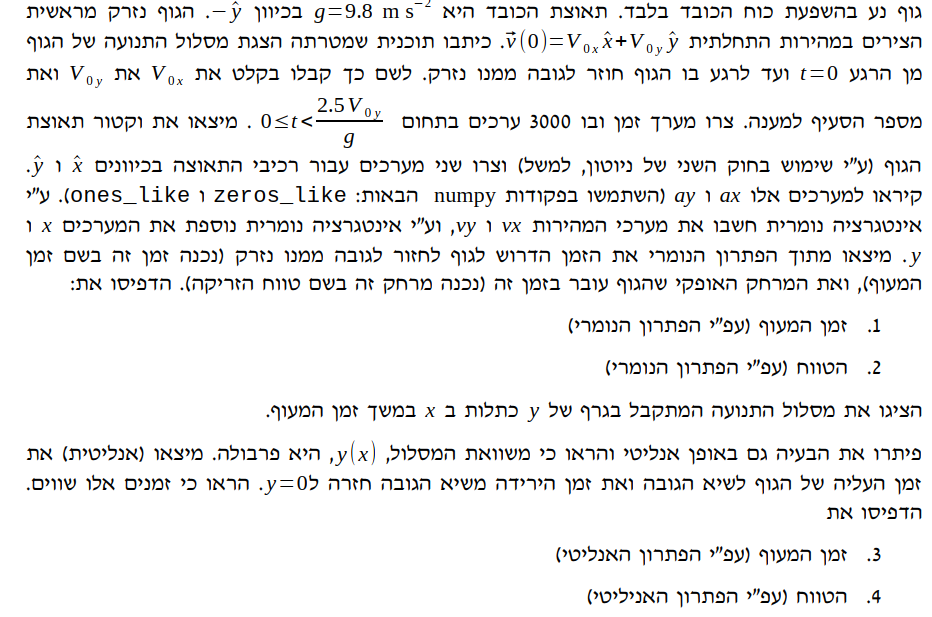

In [ ]:
import numpy as np
#import matplotlib.pyplot as plt

def zero_cross(ar):
    H1t = np.sign(ar)
    H1s = np.abs(H1t[:-1] - H1t[1:])
    return np.nonzero(H1s)[0]

V0x = float(input('enter V_ox: '))
V0y = float(input('enter V_oy: '))
qn  = int(input('enter qn: '))

g = 9.8
N = 3000
t  = np.linspace(0, 2.5*V0y/g, N)
dt = t[1] - t[0]

# Constant acceleration arrays
ax = np.zeros_like(t)
ay = -g * np.ones_like(t)

# Euler integration → velocity
vx = np.zeros_like(t); vx[0] = V0x
vy = np.zeros_like(t); vy[0] = V0y
for i in range(1, N):
    vx[i] = vx[i-1] + ax[i-1] * dt
    vy[i] = vy[i-1] + ay[i-1] * dt

# Euler integration → position
x = np.zeros_like(t)
y = np.zeros_like(t)
for i in range(1, N):
    x[i] = x[i-1] + vx[i-1] * dt
    y[i] = y[i-1] + vy[i-1] * dt

# Landing: last index where y crosses zero (positive → negative)
i = zero_cross(y)[-1]

# Linear interpolation at exact y=0 crossing
t_land = t[i] - y[i] * (t[i+1] - t[i]) / (y[i+1] - y[i])
x_land = x[i] - y[i] * (x[i+1] - x[i]) / (y[i+1] - y[i])

Ans1 = t_land   # numerical flight time
Ans2 = x_land   # numerical range

# Analytical: y(t) = V0y*t - g/2*t² = 0  →  t = 2*V0y/g
Ans3 = 2 * V0y / g        # analytical flight time
Ans4 = V0x * Ans3          # analytical range: x = V0x * t_flight
# === Plot trajectory (y vs x) ===
#plt.plot(x, y)
#plt.xlabel('x [m]'); plt.ylabel('y [m]')
#plt.title('Projectile Trajectory')
#plt.grid(True); plt.show()

Answers = [0, Ans1, Ans2, Ans3, Ans4]
print(f'{Answers[qn]:.5g}')